In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ToyotaCorolla - MLR.csv")

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
df.shape

(1436, 11)

In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


## Check Missing Values

In [8]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

## Check Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(1)

## Encoding

In [21]:
# Encode Fuel_Type
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True, dtype=int)

In [22]:
# Remove constant columns (Cylinders has only one unique value)
df_corr = df.loc[:, df.nunique() > 1]

### Correlation Heatmap

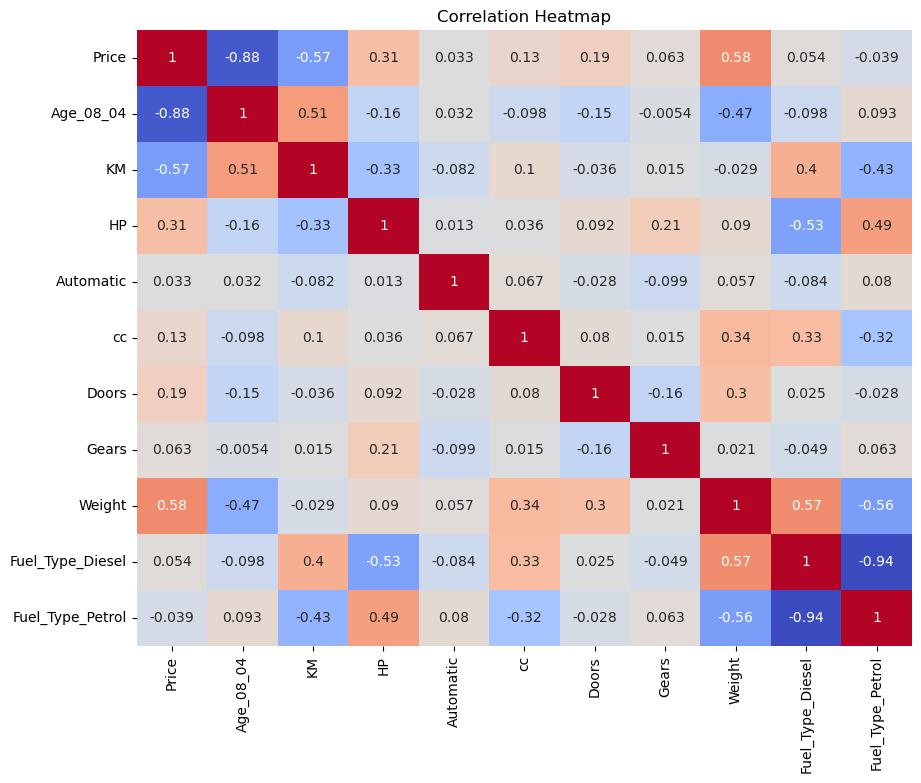

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', cbar=False)
plt.title("Correlation Heatmap")
plt.show()

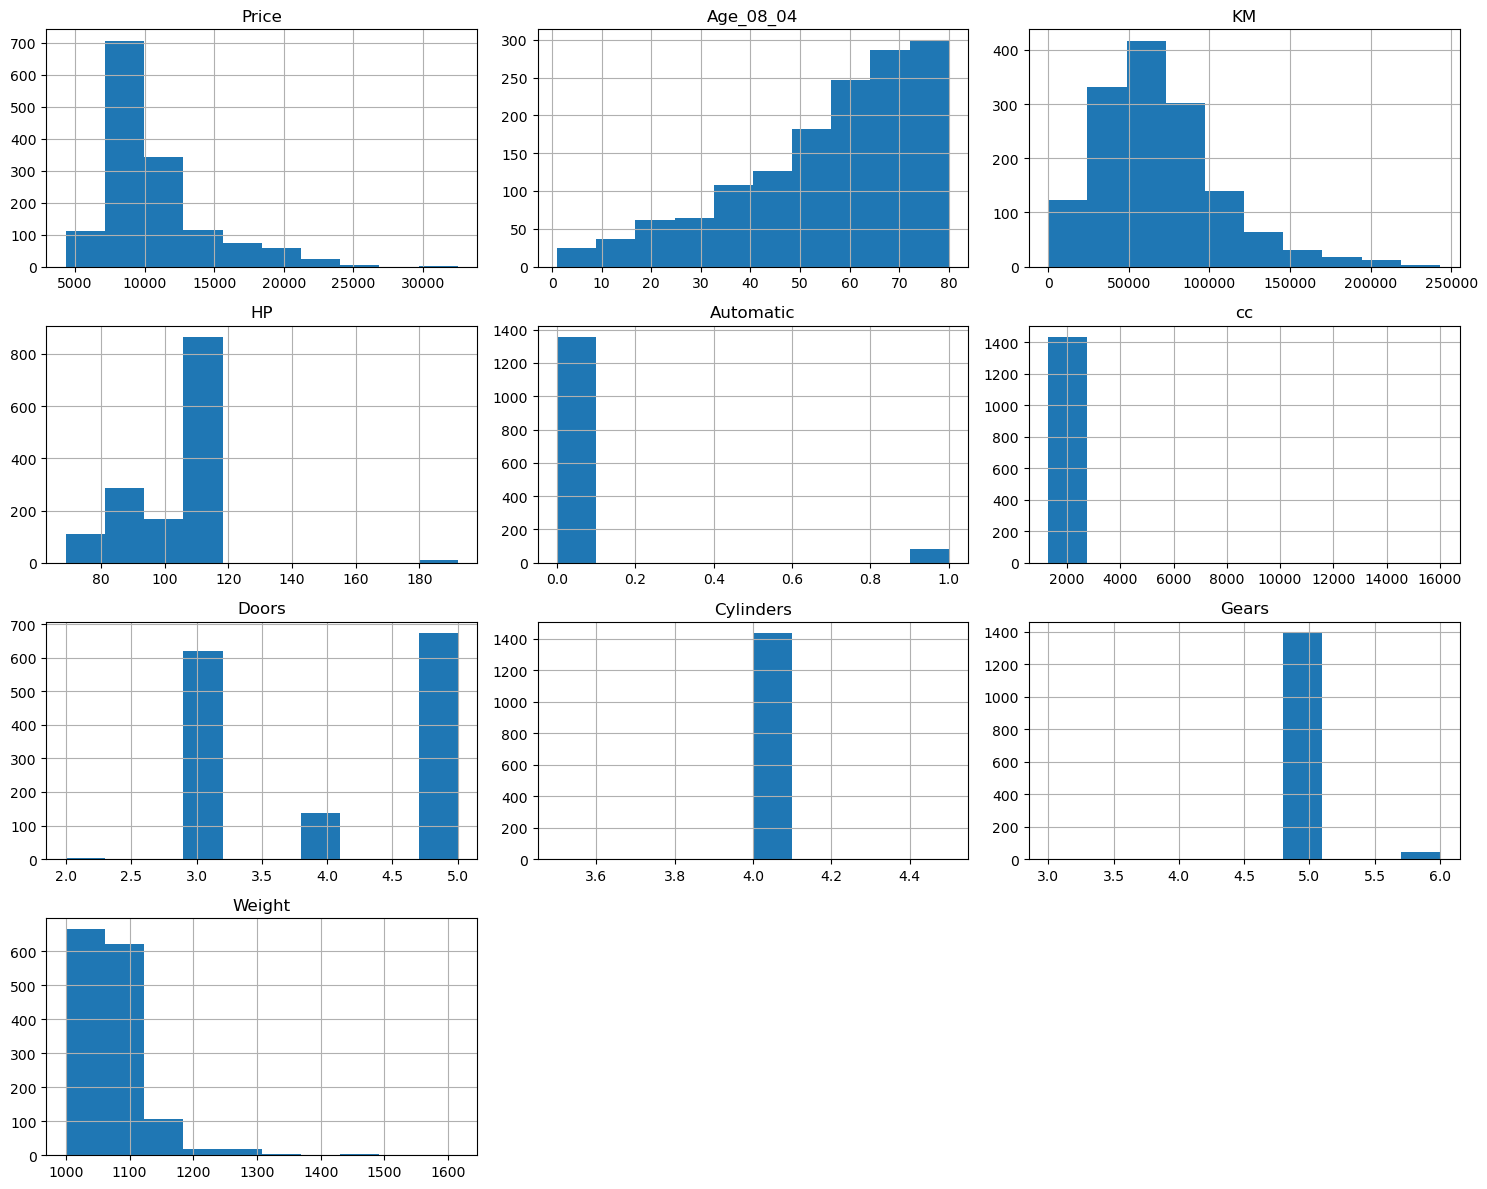

In [13]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

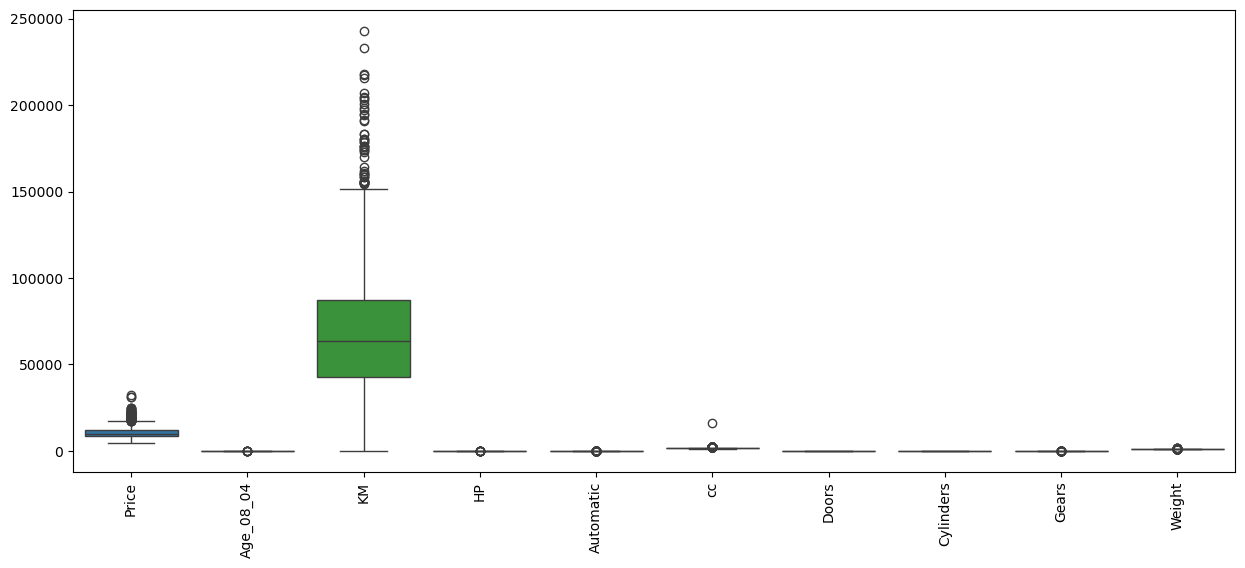

In [14]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

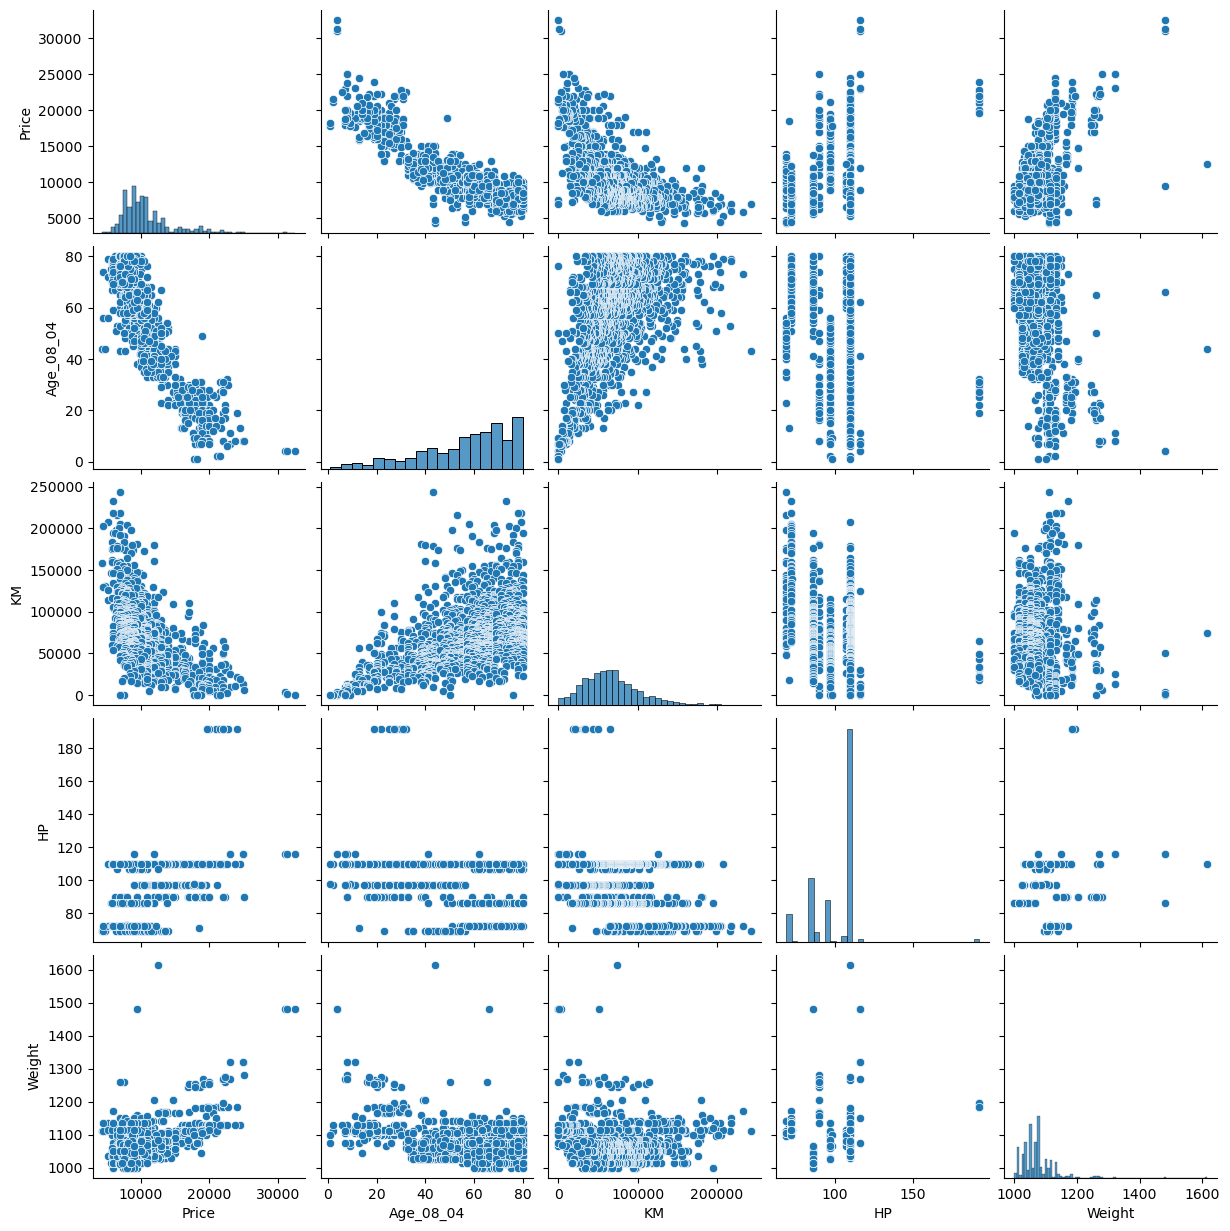

In [16]:
#PairPlot
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

## Train-Test- Split

In [26]:
from sklearn.preprocessing import StandardScaler

In [25]:
# Define Features and Target
X = df.drop('Price', axis=1)
y = df['Price']

In [27]:
# Feature Scaling
scaler = StandardScaler()

In [28]:
X = scaler.fit_transform(X)

In [29]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Model Building

### Model 1: Using all Features

In [30]:
from sklearn.linear_model import LinearRegression

mlr1 = LinearRegression()

mlr1.fit(X_train, y_train)

yhat1 = mlr1.predict(X_test)

In [32]:
#coefficients
coef1 = pd.DataFrame({
    'Feature': df.drop('Price', axis=1).columns,
    'Coefficient': mlr1.coef_
})

coef1

,Feature,Coefficient
0,Age_08_04,-2.246662e+03
1,KM,-6.085706e+02
2,HP,2.102533e+02
3,Automatic,3.413608e+01
4,cc,-1.288507e+01
5,Doors,-5.743684e+01
6,Cylinders,-7.673862e-13
7,Gears,1.039463e+02
8,Weight,1.362139e+03
9,Fuel_Type_Diesel,-2.127088e+01


## Model 2: Important Features Only

In [33]:
X2 = df[['Age_08_04','KM','HP','Weight']]

scaler = StandardScaler()
X2 = scaler.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

mlr2 = LinearRegression()

mlr2.fit(X2_train, y2_train)

yhat2 = mlr2.predict(X2_test)

In [34]:
#coefficients
coef2 = pd.DataFrame({
    'Feature':['Age_08_04','KM','HP','Weight'],
    'Coefficient':mlr2.coef_
})

coef2

,Feature,Coefficient
0,Age_08_04,-2231.693684
1,KM,-758.588405
2,HP,435.081309
3,Weight,1040.303384


## Model 3: Selected Features

In [35]:
X3 = df[['Age_08_04','HP','Weight']]

scaler = StandardScaler()
X3 = scaler.fit_transform(X3)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y,
    test_size=0.20,
    random_state=42
)

mlr3 = LinearRegression()

mlr3.fit(X3_train, y3_train)

yhat3 = mlr3.predict(X3_test)

In [37]:
# coefficiets
coef3 = pd.DataFrame({
    'Feature':['Age_08_04','HP','Weight'],
    'Coefficient':mlr3.coef_
})

coef3


,Feature,Coefficient
0,Age_08_04,-2685.898980
1,HP,639.958692
2,Weight,811.343506


## Model Evaluation

In [38]:
def eval_reg(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted")
    plt.show()

Model 1 Evaluation
Mean Absolute Error (MAE): 990.89
Mean Squared Error (MSE): 2203043.82
Root Mean Squared Error (RMSE): 1484.27
R² Score: 0.8349


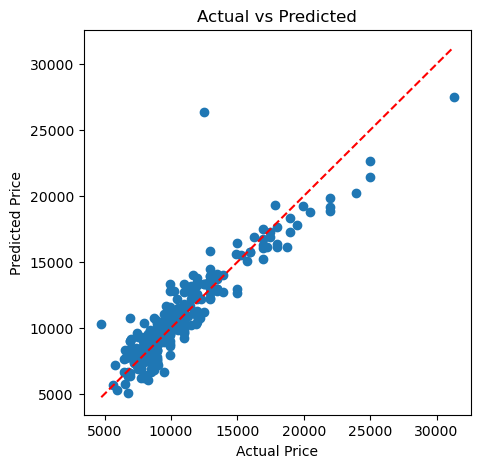

In [39]:
#Model 1
print("Model 1 Evaluation")
eval_reg(y_test, yhat1)

Model 2 Evaluation
Mean Absolute Error (MAE): 1001.20
Mean Squared Error (MSE): 1993321.01
Root Mean Squared Error (RMSE): 1411.85
R² Score: 0.8506


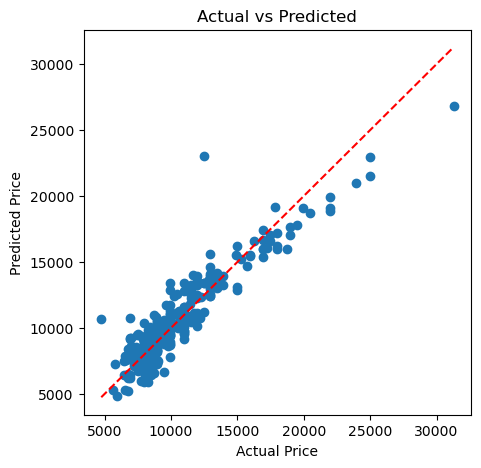

In [40]:
#Model 2
print("Model 2 Evaluation")
eval_reg(y2_test, yhat2)

Model 3 Evaluation
Mean Absolute Error (MAE): 1093.26
Mean Squared Error (MSE): 2247516.00
Root Mean Squared Error (RMSE): 1499.17
R² Score: 0.8316


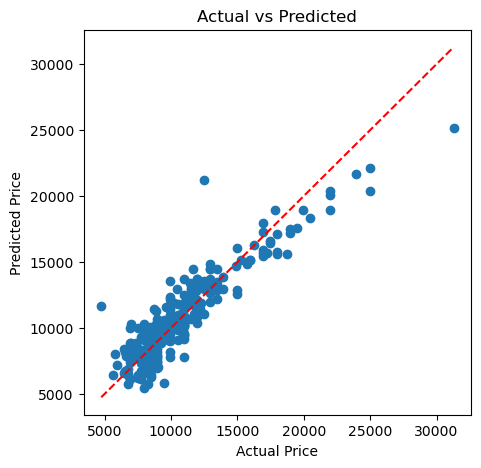

In [41]:
#Model 3 
print("Model 3 Evaluation")
eval_reg(y3_test, yhat3)

In [42]:
comparison = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'MAE': [
        mean_absolute_error(y_test, yhat1),
        mean_absolute_error(y2_test, yhat2),
        mean_absolute_error(y3_test, yhat3)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, yhat1)),
        np.sqrt(mean_squared_error(y2_test, yhat2)),
        np.sqrt(mean_squared_error(y3_test, yhat3))
    ],
    'R2 Score': [
        r2_score(y_test, yhat1),
        r2_score(y2_test, yhat2),
        r2_score(y3_test, yhat3)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Model 1,990.887274,1484.265415,0.834889
1,Model 2,1001.201747,1411.850209,0.850607
2,Model 3,1093.255209,1499.171770,0.831556


# Lasso and  Ridge 

Lasso Regression Performance
Mean Absolute Error (MAE): 991.02
Mean Squared Error (MSE): 2199939.92
Root Mean Squared Error (RMSE): 1483.22
R² Score: 0.8351


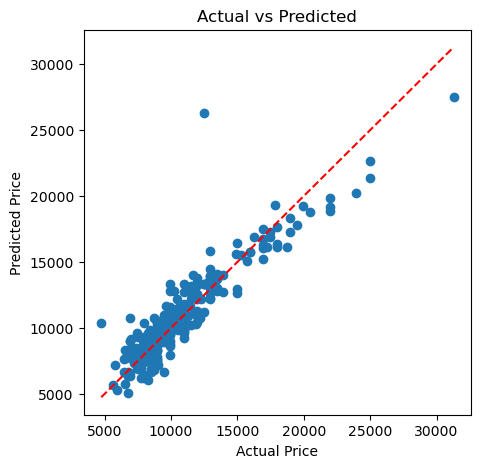

In [51]:
# Lasso Regression (Regularization)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso Regression Performance")
eval_reg(y_test, lasso_pred)

Ridge Regression Performance
Mean Absolute Error (MAE): 990.87
Mean Squared Error (MSE): 2200682.01
Root Mean Squared Error (RMSE): 1483.47
R² Score: 0.8351


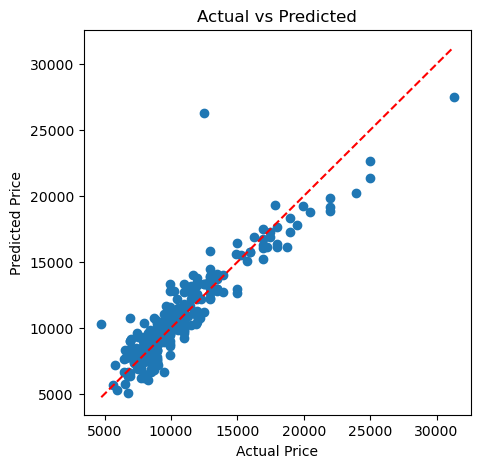

In [48]:
#Ridge regression(Regulariztion)

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Regression Performance")
eval_reg(y_test, ridge_pred)

## 1. What is Normalization & Standardization and how is it helpful?
Normalization scales data to a fixed range (usually 0 to 1), while Standardization transforms data to have mean 0 and standard deviation 1.
They improve model performance by making features comparable and helping algorithms converge faster.

## 2. What techniques can be used to address multicollinearity in multiple linear regression?
Multicollinearity can be handled by removing highly correlated variables, using VIF analysis, or applying feature selection techniques.
Alternative methods include Principal Component Analysis (PCA), Ridge Regression, and Lasso Regression.